Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')
Model Accuracy: 94.74%
New Sample Classification Result: Benign


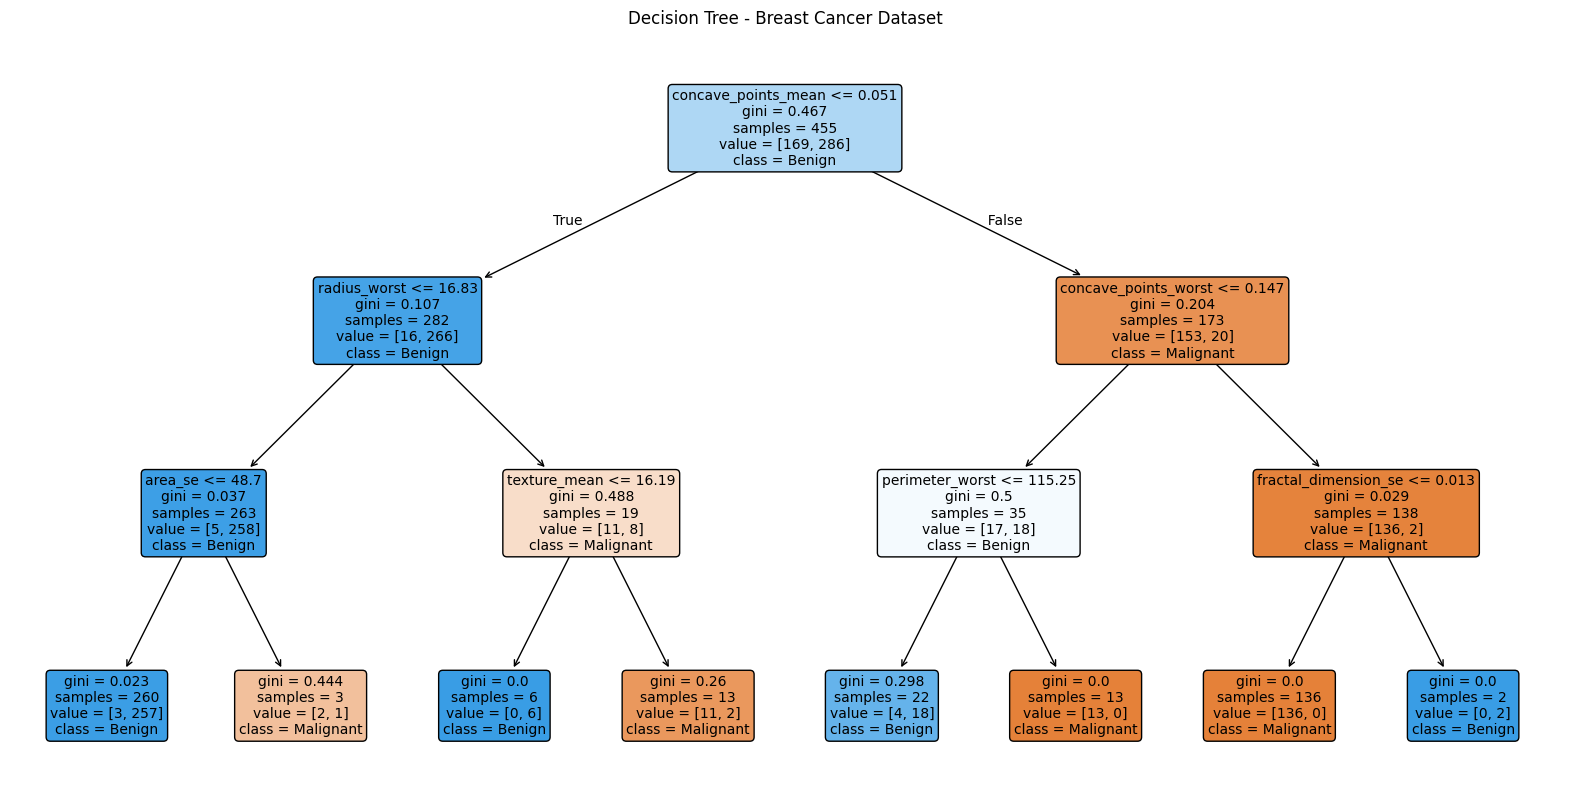

In [5]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 1. Load dataset
df = pd.read_csv('Breast Cancer Dataset.csv')

# 2. Check column names (important for safety)
print(df.columns)

# 3. Preprocessing
# Drop unnecessary columns (id and unnamed if present)
df = df.drop(['id'], axis=1)

# If there is an extra unnamed column, drop it
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)

# Separate features and target
X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']

# Convert labels: M → 0, B → 1
y = y.map({'M': 0, 'B': 1})

# 4. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train model
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 6. Prediction and accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy: {:.2f}%".format(accuracy * 100))

# 7. Classify a new sample
new_sample = X_test.iloc[[0]]
prediction = clf.predict(new_sample)

# Convert prediction to readable form
prediction_class = "Malignant" if prediction[0] == 0 else "Benign"
print("New Sample Classification Result:", prediction_class)

# 8. Visualize decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['Malignant', 'Benign'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Breast Cancer Dataset")
plt.show()


Model Accuracy: 94.74%
New Sample Classification Result: Benign


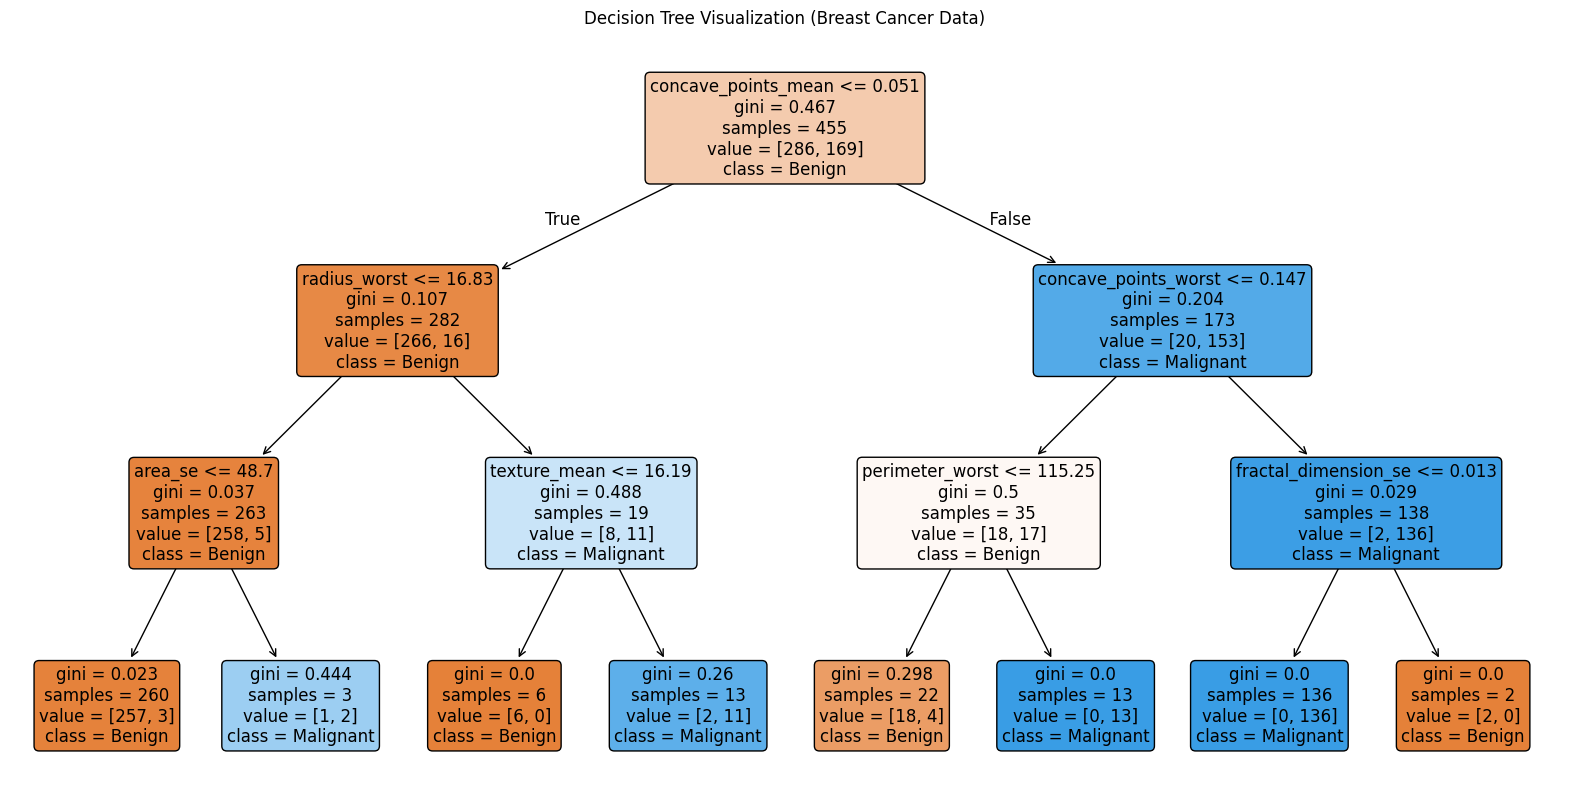

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 1. Load the dataset from your CSV file
# Ensure 'Breast Cancer Dataset.csv' is in the same folder as your notebook
df = pd.read_csv('Breast Cancer Dataset.csv')

# 2. Preprocessing
# Drop the 'id' column as it is not a predictive feature
# Separate features (X) and target (y)
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

# Convert categorical labels 'M' and 'B' to numbers 
# M (Malignant) -> 1, B (Benign) -> 0
y = y.map({'M': 1, 'B': 0})

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Decision Tree Classifier
# max_depth=3 keeps the visualization clear and readable
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 5. Make predictions and check accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# 6. Classify a new sample (as requested in the manual)
# We pick the first sample from our test set as an example
# Using double brackets [[0]] passes it as a DataFrame to avoid warnings
new_sample = X_test.iloc[[0]] 
prediction = clf.predict(new_sample)

# Map the numeric prediction back to a readable string
prediction_class = "Malignant" if prediction[0] == 1 else "Benign"
print(f"New Sample Classification Result: {prediction_class}")

# 7. Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf, 
    feature_names=X.columns, 
    class_names=['Benign', 'Malignant'], 
    filled=True, 
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree Visualization (Breast Cancer Data)")
plt.show()